In [ ]:
#Autoencoder - goal is to run on bigger dataset
#Same code as last week

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Dependencies

#connect to google drive!
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 69.2 MB/s eta 0:00:00


In [ ]:
#Dependencies
import pandas as pd
import shutil
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np

#if we resize
from PIL import Image

In [ ]:
def prep_data(sites):
  #preparing data
  for site in sites:
    print("starting site: ", site)
    site_path = "drive/MyDrive/UoM Autism Summer 2024/ABIDE MRI DATA (rest)/" + site
    pheno_csv = site_path + "/phenotypic_" + site + ".csv"
    csv = pd.read_csv(pheno_csv)
    rest_data_dir = "rest_data"

    os.makedirs("rest_data", exist_ok=True)

    #move to rest_data directory
    for index, row in csv.iterrows():
        sub_id = row['SUB_ID'] #patient id
        dx_group = row['DX_GROUP'] #diagnosis
        if dx_group == 1:
          dx_group = "ASD"
        else:
          dx_group = "CONTROL"

        # Build file path
        file_path = f"{site_path}/00{sub_id}/session_1/rest_1/rest.nii.gz"
        dest_path = f"rest_data/{site}_{sub_id}_{dx_group}_rest.nii.gz"
        # Move file
        shutil.copy(file_path, dest_path)

def explore_data(file_path):
  fmri_image = nib.load(file_path)
  image_data = fmri_image.get_fdata()
  print("Shape of example data: ", image_data.shape)

  #Axial View:
  #Slices are parallel to the plane of the face (looking at brain top down)
  #Corresponds to third dimension (z axis) --> z varies from 0 to 33
  #Taken at 150 different time points

  #AXIAL SLICE EXTRACTION
  x_shape = image_data.shape[0]
  y_shape = image_data.shape[1]
  z_shape = image_data.shape[2]
  t_shape = image_data.shape[3]

  print(x_shape, y_shape, z_shape, t_shape)

  x_positions = [0, int(x_shape/5),int(2*x_shape/5), int (x_shape/2), int(3*x_shape/5), int(4*x_shape/5), int(x_shape -1)]
  y_positions = [0, int(y_shape/5),int(2*y_shape/5),int (y_shape/2), int(3*y_shape/5), int(4*y_shape/5), int(y_shape -1)]
  z_positions = [0, int(z_shape/5),int(2*z_shape/5),int (z_shape/2), int(3*z_shape/5), int(4*z_shape/5), int(z_shape -1)]
  time_points = [0, int(t_shape/2), int(t_shape -1)]

  #Loop through to create subplots
  for z in z_positions:
      fig, axes = plt.subplots(1, 3, figsize=(15, 5))

      for i, t in enumerate(time_points):
          # Extract the axial slice at current Z and time point
          axial_slice = image_data[:, :, z, t]

          # Plot the axial slice
          axes[i].imshow(axial_slice, cmap="gray", origin="lower")
          axes[i].set_title(f"Axial Slice at Z={z}, Time Point={t}")

      # Adjust layout/show plot
      plt.tight_layout()
      plt.show()

  #Sagittal View:
  #Slices are parallel to midline, dividing brain in 2 halfs (side view)
  #Corresponds to first dimension (x axis) --> x varies from 0 to 63
  #Taken at 150 different time points

  #SAGITTAL SLICE EXTRACTION
  #Loop through to create subplots
  for x in x_positions:
      fig, axes = plt.subplots(1, 3, figsize=(15, 5))

      for i, t in enumerate(time_points):
          # Extract the sagittal slice at current X and time point
          axial_slice = image_data[x, :, :, t]

          # Plot the axial slice
          axes[i].imshow(axial_slice, cmap="gray", origin="lower")
          axes[i].set_title(f"Sagittal Slice at X={x}, Time Point={t}")

      # Adjust layout/show plot
      plt.tight_layout()
      plt.show()

  #Coronal view:
  #Slices are parallel to the face, dividing brain into anterior and posterior (front view)
  #Corresponds to second dimension (y axis) --> y varies from 0 to 63
  #Taken at 150 different time points


  #CORONAL SLICE EXTRACTION
  #Loop through to create subplots
  for y in y_positions:
      fig, axes = plt.subplots(1, 3, figsize=(15, 5))

      for i, t in enumerate(time_points):
          # Extract the coronal slice at current Y and time point
          axial_slice = image_data[:, y, :, t]

          # Plot the axial slice
          axes[i].imshow(axial_slice, cmap="gray", origin="lower")
          axes[i].set_title(f"Coronal Slice at Y={y}, Time Point={t}")

      # Adjust layout/show plot
      plt.tight_layout()
      plt.show()

#Loop through patients and save images for each view.
def get_Images():

  #make directories
  os.makedirs("axial_images", exist_ok=True)
  os.makedirs("coronal_images", exist_ok=True)
  os.makedirs("sagittal_images", exist_ok=True)

  count = 1
  items =  os.listdir("rest_data")
  items_sorted = sorted(items)
  for img in items_sorted:
    print(img, count)
    if (".nii.gz") in img:
      path = "rest_data/" + img
      fmri_img = nib.load(path)
      image_data = fmri_img.get_fdata()

      sagittal_x = int((image_data.shape[0])/2)
      coronal_y = int((image_data.shape[1])/2)
      axial_z = int((image_data.shape[2])/2)
      time = int((image_data.shape[3])/2)

      axial_slice = image_data[:,:,axial_z,time]
      plt.imshow(axial_slice)
      plt.savefig(f"axial_images/{img[:-7]}_axial_slice_{axial_z}.png")
      plt.close()

      sagittal_slice = image_data[sagittal_x,:,:,time]
      plt.imshow(sagittal_slice)
      plt.savefig(f"sagittal_images/{img[:-7]}_sagittal_slice_{sagittal_x}.png")
      plt.close()

      coronal_slice = image_data[:,coronal_y,:,time]
      plt.imshow(coronal_slice)
      plt.savefig(f"coronal_images/{img[:-7]}_coronal_slice_{coronal_y}.png")
      plt.close()
      count+=1

def separate_data():
  #make directories
  os.makedirs("axial_images/control", exist_ok=True)
  os.makedirs("coronal_images/control", exist_ok=True)
  os.makedirs("sagittal_images/control", exist_ok=True)
  os.makedirs("axial_images/ASD", exist_ok=True)
  os.makedirs("coronal_images/ASD", exist_ok=True)
  os.makedirs("sagittal_images/ASD", exist_ok=True)


  #sort axial images
  for img in os.listdir("axial_images"):
    if "ASD" in img and "png" in img:
      file_path = "axial_images/" + img
      dest_path = "axial_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "axial_images/" + img
      dest_path = "axial_images/control/" + img
      shutil.move(file_path, dest_path)
  #sort coronal images
  for img in os.listdir("coronal_images"):
    if "ASD" in img and "png" in img:
      file_path = "coronal_images/" + img
      dest_path = "coronal_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "coronal_images/" + img
      dest_path = "coronal_images/control/" + img
      shutil.move(file_path, dest_path)
  #sort sagittal images
  for img in os.listdir("sagittal_images"):
    if "ASD" in img and "png" in img:
      file_path = "sagittal_images/" + img
      dest_path = "sagittal_images/ASD/" + img
      shutil.move(file_path, dest_path)
    if "CONTROL" in img and "png" in img:
      file_path = "sagittal_images/" + img
      dest_path = "sagittal_images/control/" + img
      shutil.move(file_path, dest_path)




In [ ]:
def preprocess_data():
  #sites = ['CALTECH', 'KKI','OLIN', 'MAX_MUN', 'CMU', 'NYU', 'OHSU', 'SDSU', 'SBL', 'STANFORD',
           #'TRINITY,' 'UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]

  #explore_data(file_path)
  #prepare_data(sites)
  #get_Images()
  #separate_data()

preprocess_data()

In [ ]:

!cp -r "/content/axial_images" "/content/drive/MyDrive/UoM Autism Summer 2024"
!cp -r "/content/coronal_images" "/content/drive/MyDrive/UoM Autism Summer 2024"
!cp -r "/content/sagittal_images" "/content/drive/MyDrive/UoM Autism Summer 2024"

In [ ]:

def resize_image(image_path, target_size=(256, 256)):
  print(image_path)
  img = Image.open(image_path)
  img_resized = img.resize(target_size, Image.LANCZOS)
  return img_resized

def process_and_move_images(source_dir, target_dir):
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    for filename in os.listdir(source_dir):
        if filename.endswith(".png"):  # Process only .png files
            source_path = source_dir + "/" + filename
            target_path = target_dir + "/" + filename

            # Resize image
            resized_image = resize_image(source_path)

            # Save resized image to target directory
            resized_image.save(target_path)
            #print(f"Resized and moved: {filename}")


# Example usage
views = ["axial", "coronal", "sagittal"]
for view in views:
  source_directory = f"/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_{view}_images/control"
  target_directory = f"/content/ABIDE_I_rest_{view}_images_resized/control"
  process_and_move_images(source_directory, target_directory)
  #source_directory = f"/content/drive/MyDrive/UoM Autism Summer 2024/ABIDE_I_rest_{view}_images/ASD"
  #target_directory = f"/content/ABIDE_I_rest_{view}_images_resized/ASD"
  #process_and_move_images(source_directory, target_directory)
  print(f"{view} done")

####Explore Data: Determining best cuts

Chose middle for each in the end... potentially worth exploring other slices?

In [ ]:
#Shape of site CALTECH data:  (64, 64, 34, 150)
#explore_data("/content/rest_data/CALTECH_51456_ASD_rest.nii.gz")
#best cuts: z=17, x=32, y=32, t=75

#shape of site CMU data: (64 64 28 240)
#explore_data("/content/rest_data/CMU_50642_ASD_rest.nii.gz")
#best cuts: z=14, x=32, y=32, t=120


#Shape of site KKI data:  (96, 96, 47, 156)
#explore_data("/content/rest_data/KKI_50772_CONTROL_rest.nii.gz")
#best cuts: z=23, x=48, y=48, t=78


#Shape of site MAX_MUN data: 64 64 28 120
#explore_data("/content/rest_data/MAX_MUN_51318_ASD_rest.nii.gz")
#best cuts: z=14, x=32, y=32, t=60


#Shape of site OLIN data: 64 64 29 210
#explore_data("/content/rest_data/OLIN_50118_ASD_rest.nii.gz")
#best cuts: z=14, x=32, y=32, t=105




#### Visualize a sample AXIAL ASD/Control from each site

In [ ]:
def visualizeSamplesFromSites(orientation):
  sites = ['CALTECH', 'KKI','OLIN', 'MAX_MUN', 'CMU', 'NYU', 'OHSU', 'SDSU', 'SBL', 'STANFORD',
           'TRINITY', 'UCLA_1', 'UCLA_2', 'LEUVEN_1', 'LEUVEN_2', 'UM_1', 'UM_2', 'PITT', 'USM', 'YALE' ]
  for site in sites:
    directory_ASD = "/content/ABIDE_I_rest_" + orientation + "_images_resized/ASD/"
    directory_control = "/content/ABIDE_I_rest_" + orientation + "_images_resized/control/"
    print("SITE: ", site)
    print("ASD IMAGE: ")
    for image in os.listdir(directory_ASD):
      if site in image:
          file_path = directory_ASD + image
          img = mpimg.imread(file_path)
          plt.imshow(img)
          plt.axis('off')
          plt.title('ASD Image')  # Add a title if desired
          plt.show()

          print("Shape:", img.shape)
          print()
          break
    print("CONTROL IMAGE: ")
    for image in os.listdir(directory_control):
      if site in image:
          file_path = directory_control + image
          img = mpimg.imread(file_path)
          plt.imshow(img)
          plt.axis('off')
          plt.title('ASD Image')  # Add a title if desired
          plt.show()

          print("Shape:", img.shape)
          print()
          break
    print()
    print()

visualizeSamplesFromSites("axial")
#visualizeSamplesFromSites("coronal")
#visualizeSamplesFromSites("sagittal")


### Model:

In [ ]:
#dependencies
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from sklearn.model_selection import train_test_split
import numpy as np
import os
from PIL import Image

import pandas as pd
import shutil
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

#if we resize
from PIL import Image

In [ ]:

def getImageNames(directory):
  images = []
  for filename in os.listdir(directory):
        if filename.endswith(".png"):
          path = directory + "/" + filename
          images.append(path)
  return np.array(images)

def getSets(control_dir, autistic_dir):
  X_control = getImageNames(control_dir)
  X_autistic = getImageNames(autistic_dir)
  # Split control data into training and validation sets
  X_train_control, X_test_control = train_test_split(X_control, test_size=0.2, random_state=42)
  X_train_control, X_val_control = train_test_split(X_train_control, test_size=0.2, random_state=42)
  X_train_ASD_not_to_use, X_test_ASD = train_test_split(X_autistic, test_size=0.2, random_state=42)
  print("X_train_control of size: ", X_train_control.shape)
  print("X_val_control of size: ", X_val_control.shape)
  print("X_test_control of size: ", X_test_control.shape)
  print("X_test_ASD of size: ", X_test_ASD.shape)
  return X_train_control, X_val_control, X_test_control, X_test_ASD

#Visualize sets - just to see what data looks like

def visualizeData(set, setName):
  print("Visualizing set: ", setName)

  fig, axes = plt.subplots(1, len(set), figsize=(15, 3))

  for i, filename in enumerate(set):
      img = Image.open(filename)
      axes[i].imshow(img)
      axes[i].axis('off')

  plt.tight_layout()
  plt.show()

def load_and_preprocess_images(set):
    images = []
    for filename in set:
      img = load_img(filename)
      img = np.array(img) / 255.0
      images.append(img)
    return np.array(images)
# Function to plot original, reconstructed, and subtraction images
def plot_images(original, reconstructed, title):
    fig, axes = plt.subplots(3, len(original), figsize=(15, 6))

    # Plot original images
    for i in range(len(original)):
        axes[0, i].imshow(original[i], cmap='gray')
        axes[0, i].set_title('Original')
        axes[0, i].axis('off')

    # Plot reconstructed images
    for i in range(len(reconstructed)):
        axes[1, i].imshow(reconstructed[i], cmap='gray')
        axes[1, i].set_title('Reconstructed')
        axes[1, i].axis('off')

    # Plot subtraction (difference) images
    for i in range(len(original)):
        subtracted_img = np.abs(original[i] - reconstructed[i])
        axes[2, i].imshow(subtracted_img, cmap='gray')
        axes[2, i].set_title('Difference')
        axes[2, i].axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_image_differences(image_1_path, image_2_path):
  # Load images
  img1 = Image.open(image_1_path)
  img2 = Image.open(image_1_path)

  # Convert images to numpy arrays and subtract
  img1_array = np.array(img1)
  img2_array = np.array(img2)
  subtracted_img = np.abs(img1_array - img2_array)

  # Plot original images and subtraction result
  fig, axes = plt.subplots(1, 3, figsize=(12, 4))

  # Plot first image
  axes[0].imshow(img1_array, cmap='gray')
  axes[0].set_title('Image 1')
  axes[0].axis('off')

  # Plot second image
  axes[1].imshow(img2_array, cmap='gray')
  axes[1].set_title('Image 2')
  axes[1].axis('off')

  # Plot subtraction result
  axes[2].imshow(subtracted_img, cmap='gray')
  axes[2].set_title('Subtraction Result')
  axes[2].axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:

def autoencoder(X_train_control, X_val_control, X_test_control, X_test_ASD):
  input_img = Input(shape=(256, 256, 3))  # adjust if we resize

  # Encoder
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same')(x)

  # Decoder
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

  # Autoencoder model
  autoencoder = Model(input_img, decoded)
  autoencoder.compile(optimizer='adam', loss='mse')

  # Train the autoencoder
  history = autoencoder.fit(X_train_control, X_train_control,
                  epochs=10,
                  batch_size=32,
                  shuffle=True,
                  validation_data=(X_val_control, X_val_control))

  #plot model history
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Model loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Train', 'Validation'], loc='upper right')
  plt.show()


  #predict on test data
  reconstructed_control = autoencoder.predict(X_test_control)
  reconstructed_ASD = autoencoder.predict(X_test_ASD)

  # Calculate MSE for control and ASD MRIs
  mse_control = np.mean(np.square(reconstructed_control - X_test_control))
  mse_ASD = np.mean(np.square(reconstructed_ASD - X_test_ASD))

  print(f"MSE on test set (control MRIs): {mse_control}")
  print(f"MSE on test set (ASD MRIs): {mse_ASD}")

  #VISUALIZE RECONSTRUCTIONS
  # Select a few examples from X_test_control and X_test_ASD
  num_examples = 5  # Number of examples to visualize
  examples_control = X_test_control[:num_examples]
  examples_ASD = X_test_ASD[:num_examples]

  # Plot examples for control MRIs
  plot_images(examples_control, reconstructed_control[:num_examples], title='Control MRI Reconstruction')

  # Plot examples for ASD MRIs
  plot_images(examples_ASD, reconstructed_ASD[:num_examples], title='ASD MRI Reconstruction')


X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)
X_train_control images shape:  (366, 256, 256, 3)
X_val_control images shape:  (92, 256, 256, 3)
X_test_control images shape:  (115, 256, 256, 3)
X_test_ASD images shape:  (108, 256, 256, 3)
Epoch 1/10
12/12 [==============================] - 3s 139ms/step - loss: 0.1114 - val_loss: 0.0809
Epoch 2/10
12/12 [==============================] - 1s 90ms/step - loss: 0.0667 - val_loss: 0.0429
Epoch 3/10
12/12 [==============================] - 1s 89ms/step - loss: 0.0282 - val_loss: 0.0190
Epoch 4/10
12/12 [==============================] - 1s 86ms/step - loss: 0.0184 - val_loss: 0.0173
Epoch 5/10
12/12 [==============================] - 1s 89ms/step - loss: 0.0168 - val_loss: 0.0159
Epoch 6/10
12/12 [==============================] - 1s 91ms/step - loss: 0.0159 - val_loss: 0.0153
Epoch 7/10
12/12 [==============================] - 1s 90ms/step - loss: 0.0154 - val_loss:

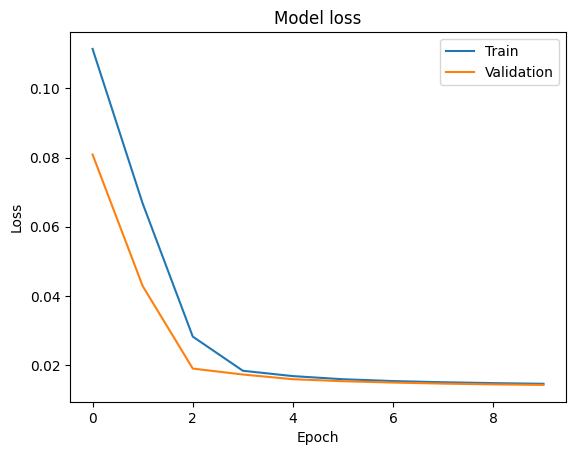

4/4 [==============================] - 0s 22ms/step
MSE on test set (control MRIs): 0.014753806897188007
MSE on test set (ASD MRIs): 0.014449785332477096


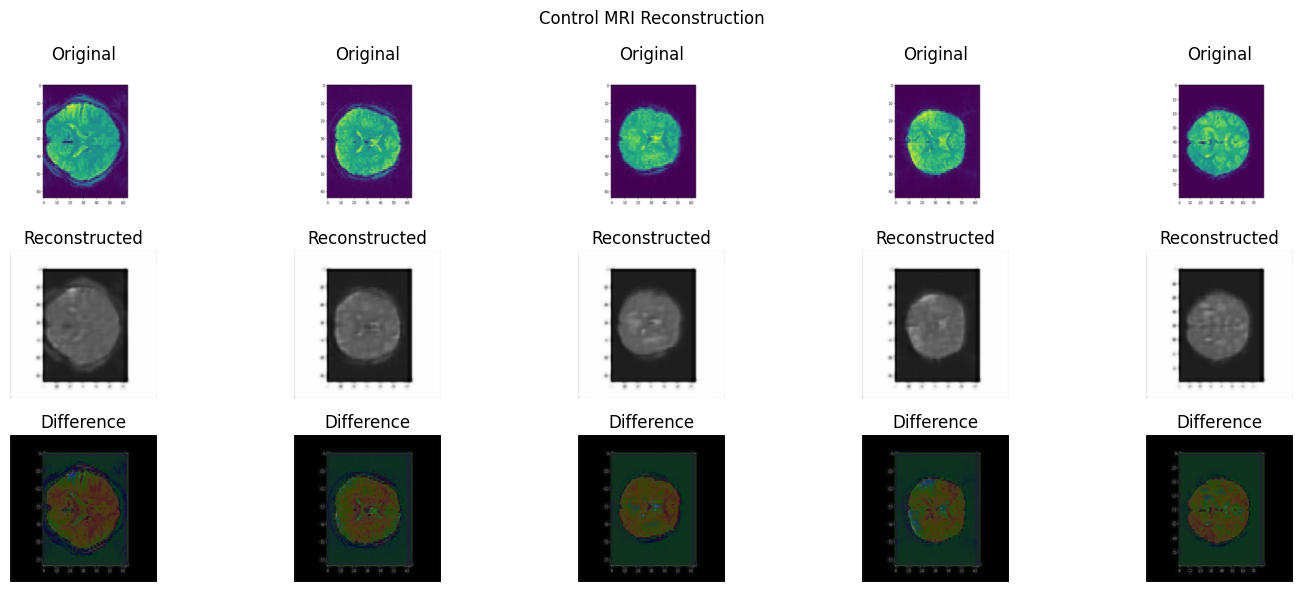

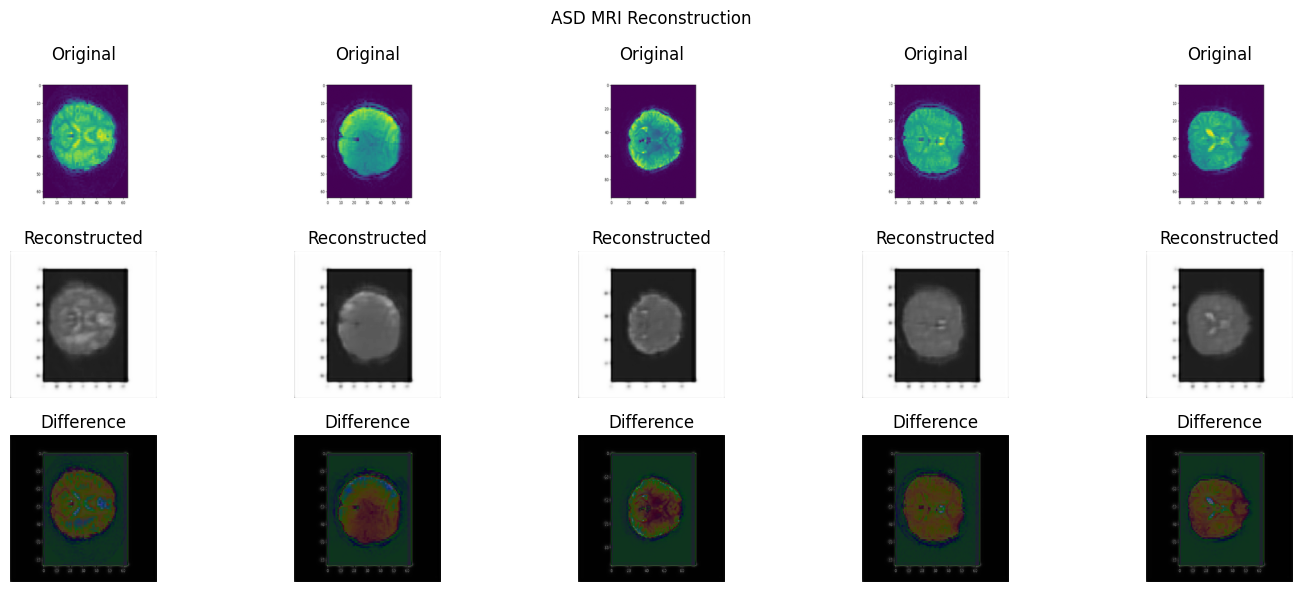

In [ ]:
def runModel(view):
  control_dir = "/content/ABIDE_I_rest_axial_images_resized/control"
  autistic_dir = "/content/ABIDE_I_rest_axial_images_resized/ASD"
  X_train_control, X_val_control, X_test_control, X_test_ASD = getSets(control_dir, autistic_dir)

  #visualizeData(X_test_control, "X_test_control")
  #visualizeData(X_test_ASD, "X_test_ASD")

  #print("Plotting an example difference between control and ASD")
  #plot_image_differences(X_test_control[0], X_test_ASD[0])

  X_train_control = load_and_preprocess_images(X_train_control)
  X_val_control = load_and_preprocess_images(X_val_control)
  X_test_ASD = load_and_preprocess_images(X_test_ASD)
  X_test_control = load_and_preprocess_images(X_test_control)
  print("X_train_control images shape: ", X_train_control.shape)
  print("X_val_control images shape: ", X_val_control.shape)
  print("X_test_control images shape: ", X_test_control.shape)
  print("X_test_ASD images shape: ", X_test_ASD.shape)

  autoencoder(X_train_control, X_val_control, X_test_control, X_test_ASD)


runModel("axial")

X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)
X_train_control images shape:  (366, 256, 256, 3)
X_val_control images shape:  (92, 256, 256, 3)
X_test_control images shape:  (115, 256, 256, 3)
X_test_ASD images shape:  (108, 256, 256, 3)
Epoch 1/10
12/12 [==============================] - 3s 142ms/step - loss: 0.1050 - val_loss: 0.0782
Epoch 2/10
12/12 [==============================] - 1s 88ms/step - loss: 0.0648 - val_loss: 0.0456
Epoch 3/10
12/12 [==============================] - 1s 86ms/step - loss: 0.0307 - val_loss: 0.0174
Epoch 4/10
12/12 [==============================] - 1s 88ms/step - loss: 0.0180 - val_loss: 0.0175
Epoch 5/10
12/12 [==============================] - 1s 90ms/step - loss: 0.0166 - val_loss: 0.0158
Epoch 6/10
12/12 [==============================] - 1s 94ms/step - loss: 0.0157 - val_loss: 0.0151
Epoch 7/10
12/12 [==============================] - 1s 101ms/step - loss: 0.0152 - val_loss

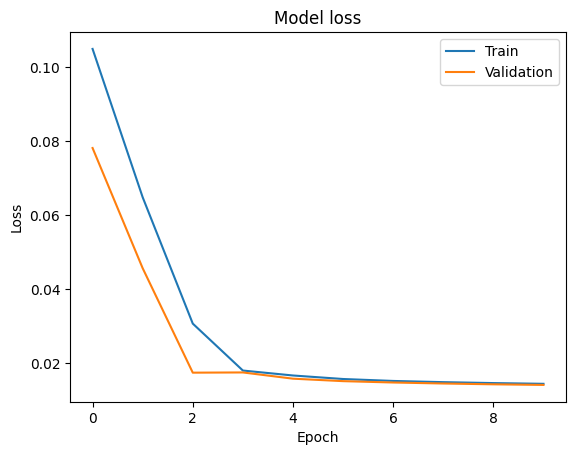

4/4 [==============================] - 0s 22ms/step
MSE on test set (control MRIs): 0.014519779444820129
MSE on test set (ASD MRIs): 0.014241666802910995


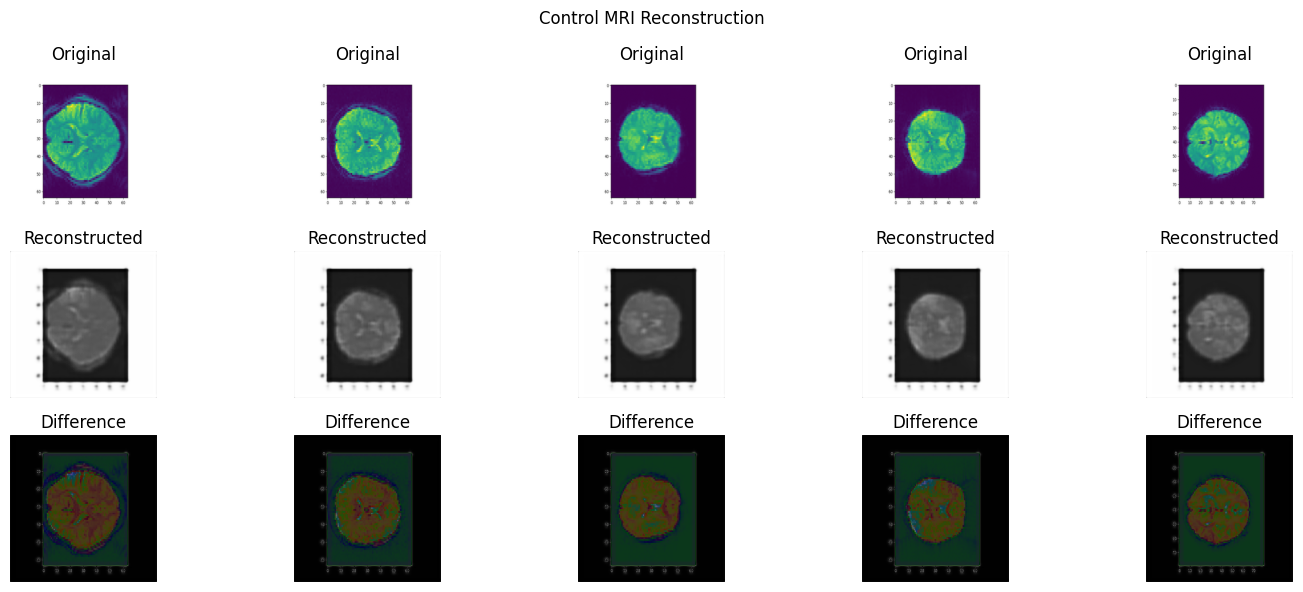

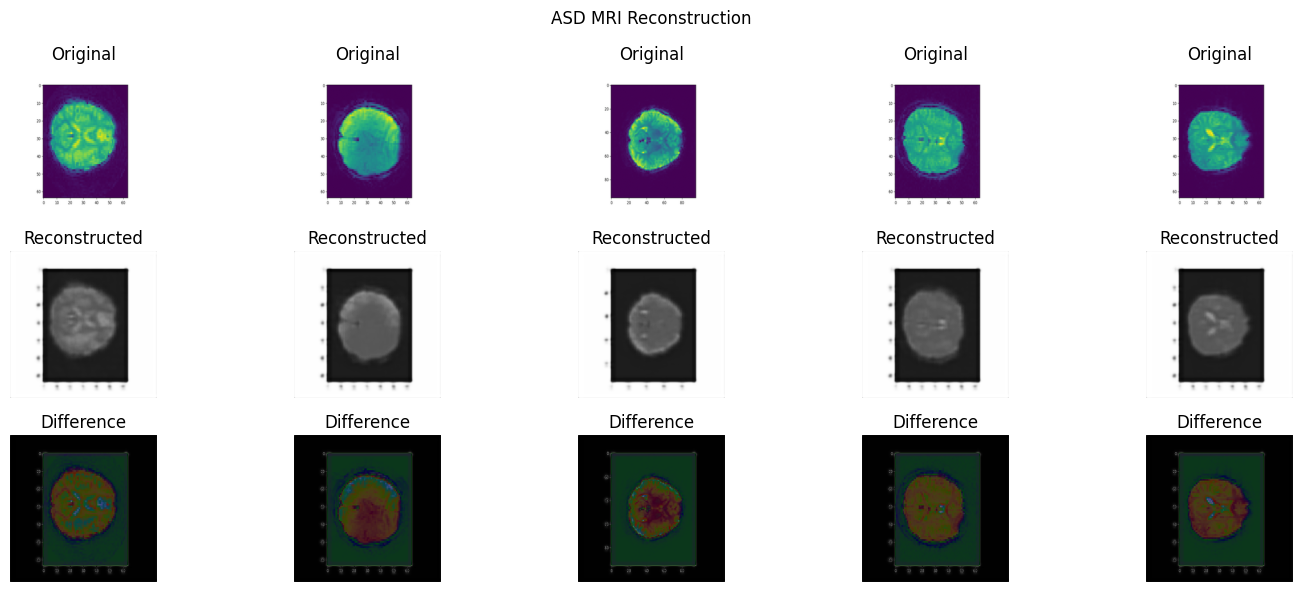

In [ ]:
runModel("sagittal")

X_train_control of size:  (366,)
X_val_control of size:  (92,)
X_test_control of size:  (115,)
X_test_ASD of size:  (108,)
X_train_control images shape:  (366, 256, 256, 3)
X_val_control images shape:  (92, 256, 256, 3)
X_test_control images shape:  (115, 256, 256, 3)
X_test_ASD images shape:  (108, 256, 256, 3)
Epoch 1/10
12/12 [==============================] - 3s 147ms/step - loss: 0.1132 - val_loss: 0.0823
Epoch 2/10
12/12 [==============================] - 1s 87ms/step - loss: 0.0672 - val_loss: 0.0439
Epoch 3/10
12/12 [==============================] - 1s 89ms/step - loss: 0.0318 - val_loss: 0.0216
Epoch 4/10
12/12 [==============================] - 1s 88ms/step - loss: 0.0201 - val_loss: 0.0175
Epoch 5/10
12/12 [==============================] - 1s 89ms/step - loss: 0.0171 - val_loss: 0.0162
Epoch 6/10
12/12 [==============================] - 1s 88ms/step - loss: 0.0161 - val_loss: 0.0155
Epoch 7/10
12/12 [==============================] - 1s 88ms/step - loss: 0.0155 - val_loss:

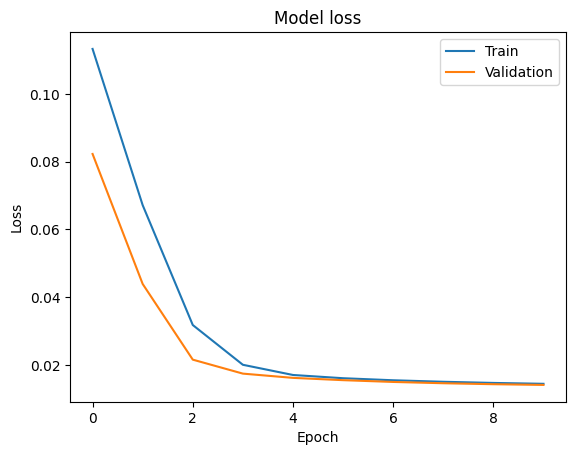

4/4 [==============================] - 0s 28ms/step
MSE on test set (control MRIs): 0.01460835203609135
MSE on test set (ASD MRIs): 0.014320081532438324


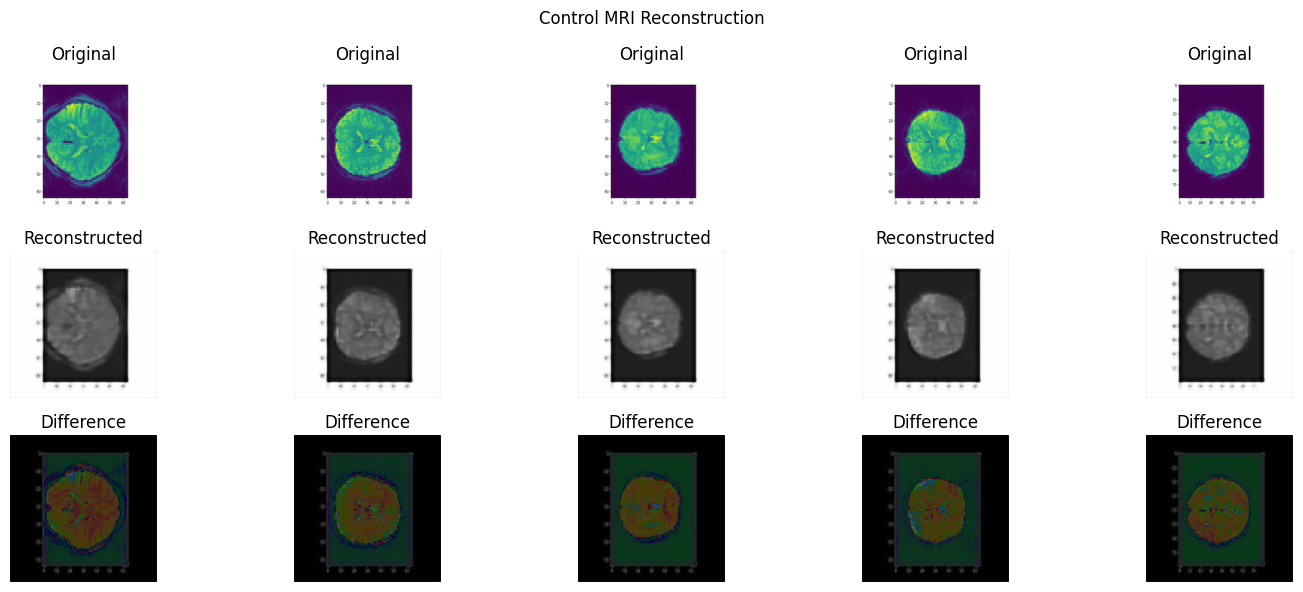

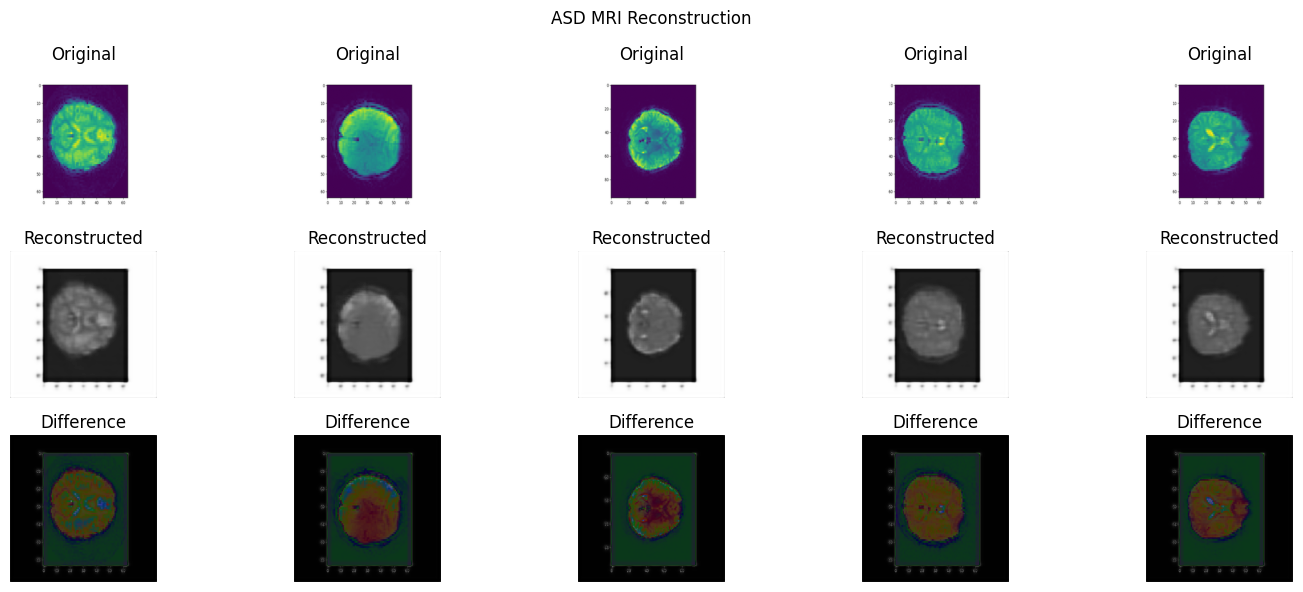

In [ ]:
runModel("coronal")

Questions:
- Look at image subtraction
- Should I try working with nii.gz instead of png?
- or mprage data?
- Resizing???


Need bigger dataset STILL
Need to do model history still
